<a href="https://colab.research.google.com/github/srikanth713/Machine_Learning/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction using Keras

This notebook demonstrates how to build a simple house price prediction model using Keras. We will cover data loading, preprocessing, model definition, training, and evaluation.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

For demonstration purposes, we will create a synthetic dataset. In a real-world scenario, you would load your dataset using `pd.read_csv()`, `pd.read_sql()`, or similar methods.

In [2]:
# Generate synthetic data
np.random.seed(42)
num_samples = 1000

# Features: size (sqft), number of bedrooms, age of house, distance to city center
size = np.random.normal(loc=1500, scale=300, size=num_samples)
bedrooms = np.random.randint(2, 6, size=num_samples)
age = np.random.randint(1, 70, size=num_samples)
distance_to_city = np.random.uniform(1, 20, size=num_samples)

# Target: price (in thousands of dollars)
# Price is a function of features with some noise
price = (size * 0.1) + (bedrooms * 20) + (100 - age * 0.5) - (distance_to_city * 3) + np.random.normal(loc=0, scale=50, size=num_samples)
price = np.maximum(price, 50) # Ensure prices are not negative or too low

data = pd.DataFrame({
    'size_sqft': size,
    'bedrooms': bedrooms,
    'house_age': age,
    'distance_to_city_km': distance_to_city,
    'price_k_usd': price
})

display(data.head())

,size_sqft,bedrooms,house_age,distance_to_city_km,price_k_usd
0,1649.014246,4,43,14.772273,248.323145
1,1458.520710,5,1,17.675293,210.263531
2,1694.306561,2,51,1.791480,228.726581
3,1956.908957,5,24,8.555304,296.408926
4,1429.753988,4,24,15.483872,324.946309


## 3. Data Preprocessing

This step involves splitting the data into training and testing sets, and scaling numerical features. For a real dataset, you might also need to handle missing values, encode categorical features, or perform feature engineering.

In [3]:
# Define features (X) and target (y)
X = data.drop('price_k_usd', axis=1)
y = data['price_k_usd']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

display(X_train_scaled_df.head())

Training features shape: (800, 4)
Testing features shape: (200, 4)
Training target shape: (800,)
Testing target shape: (200,)


,size_sqft,bedrooms,house_age,distance_to_city_km
29,-0.323727,0.459262,0.734042,0.292157
535,0.022387,1.346726,0.018028,0.392325
695,-0.341949,-0.428201,1.245480,0.376156
557,-0.467508,-1.315665,-0.697985,-1.760945
836,1.556611,-0.428201,0.529466,-1.436494


## 4. Define the Keras Model

We will create a simple neural network with a few dense layers. The output layer will have a single neuron with no activation function, suitable for regression tasks.

In [4]:
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1) # Output layer for regression
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile and Train the Model

We'll use `Adam` optimizer and `mean_squared_error` as the loss function, which is common for regression problems.

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 75426.5312 - mae: 267.0288 - val_loss: 77899.0000 - val_mae: 271.1425
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 74972.0781 - mae: 266.1890 - val_loss: 77292.4219 - val_mae: 270.0387
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 74197.6562 - mae: 264.7486 - val_loss: 76207.5312 - val_mae: 268.0538
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 72842.5391 - mae: 262.2010 - val_loss: 74363.7969 - val_mae: 264.6526
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 70610.2656 - mae: 257.9523 - val_loss: 71424.1328 - val_mae: 259.1614
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 67202.3047 - mae: 251.3094 - val_loss: 67072.6484 - val_mae: 250.8284
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 62292.8281 - mae: 241.5130 - val_loss: 61072.4297 - val_mae: 238.9148
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 55731.0938 - mae: 227.7405 - val_loss:

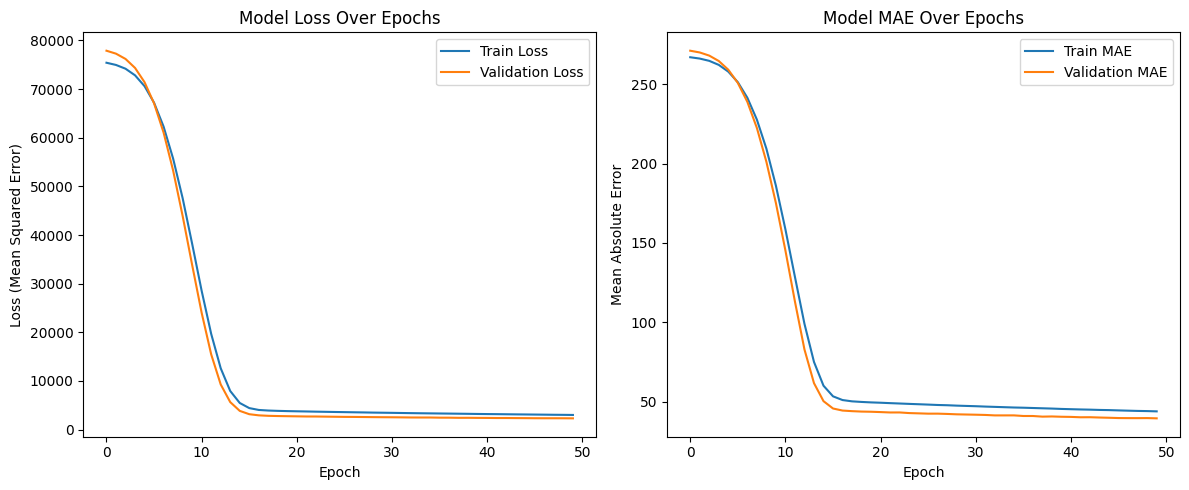

In [5]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Evaluate the Model

Evaluate the model's performance on the test set and visualize predictions.

Test Loss (Mean Squared Error): 2813.6709
Test MAE (Mean Absolute Error): 42.6185
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Mean Squared Error on Test Set: 2813.6712
R-squared on Test Set: 0.3260


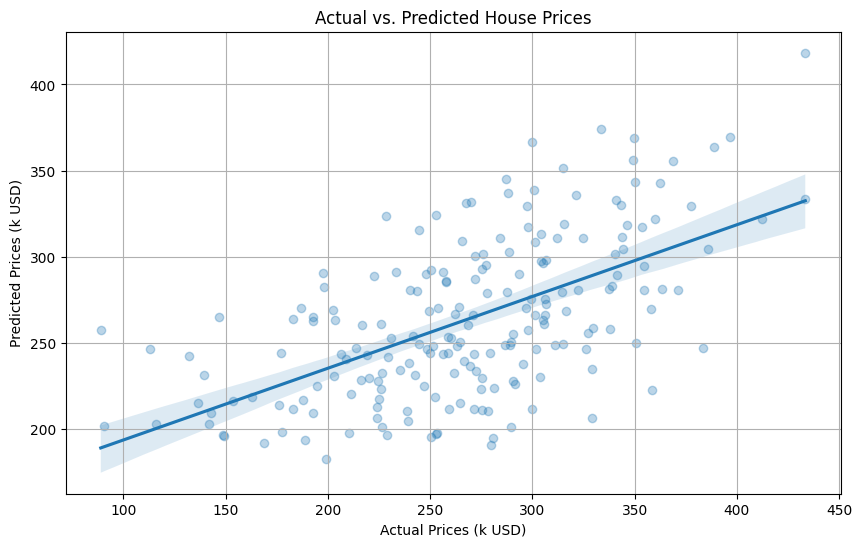

In [6]:
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss (Mean Squared Error): {loss:.4f}")
print(f"Test MAE (Mean Absolute Error): {mae:.4f}")

y_pred = model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error on Test Set: {mse:.4f}")
print(f"R-squared on Test Set: {r2:.4f}")

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Prices (k USD)')
plt.ylabel('Predicted Prices (k USD)')
plt.title('Actual vs. Predicted House Prices')
plt.grid(True)
plt.show()